# Работа по теме "Временные ряды"

## Описание

Работа предполагает самостоятельное исследование данных и построение моделей прогнозирования временных рядов.

Основная задача работы - научиться работать с временными рядами, прогнозировать их.

Предлагается один набор данных.

Примерные критерии оценки:
- представленные данные изучены и описаны;
- данные предобработаны при необходимости, разделены на выборки;
- показано исследование данных на предмет автокорреляций, оптимальных лагов;
- рассмотрено не менее двух моделей прогнозирования;
- рассмотрены различные метрики для оценки, при описании результатов метрики верно интерпретированы.

В результате необходимо получить наилучшую модель прогнозирования временных рядов, при этом основную метрику разрешается выбрать самостоятельно, объяснив свой выбор. Также должен быть показан весь процесс исследования данных и настройки моделей.

## Импорт библиотек

In [168]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Температурные изменения

Набор данных `MLTempDataset.csv` содержит показания комнатной температуры в зависимости от времени.

Требуется построить модель, позволяющую прогнозировать температуру.

#### Считаем и посмотрим на данные

In [143]:
df = pd.read_csv('MLTempDataset.csv')
df = df.drop('Unnamed: 0', axis = 1)
df.head()

,Datetime,Hourly_Temp
0,2022-01-04 00:00:00,20.867
1,2022-01-04 01:00:00,21.000
2,2022-01-04 02:00:00,20.867
3,2022-01-04 03:00:00,20.650
4,2022-01-04 04:00:00,20.400


#### Посмотрим на пропущенные значения и типы данных

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     7056 non-null   object 
 1   Hourly_Temp  7056 non-null   float64
dtypes: float64(1), object(1)
memory usage: 110.4+ KB


#### Изменим тип данных на соответствующий действительности и настроим индексы

In [145]:
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y-%m-%d %H:%M:%S')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Datetime     7056 non-null   datetime64[ns]
 1   Hourly_Temp  7056 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 110.4 KB


In [146]:
df.set_index('Datetime', inplace=True)
df.head()

,Hourly_Temp
Datetime,
2022-01-04 00:00:00,20.867
2022-01-04 01:00:00,21.000
2022-01-04 02:00:00,20.867
2022-01-04 03:00:00,20.650
2022-01-04 04:00:00,20.400


In [147]:
df.index.is_monotonic_increasing # то есть данные не имеют разрывов, монотонные

True

#### Попробуем построить график наших данных

Text(0.5, 1.0, 'График температуры в комнате (1h) ')

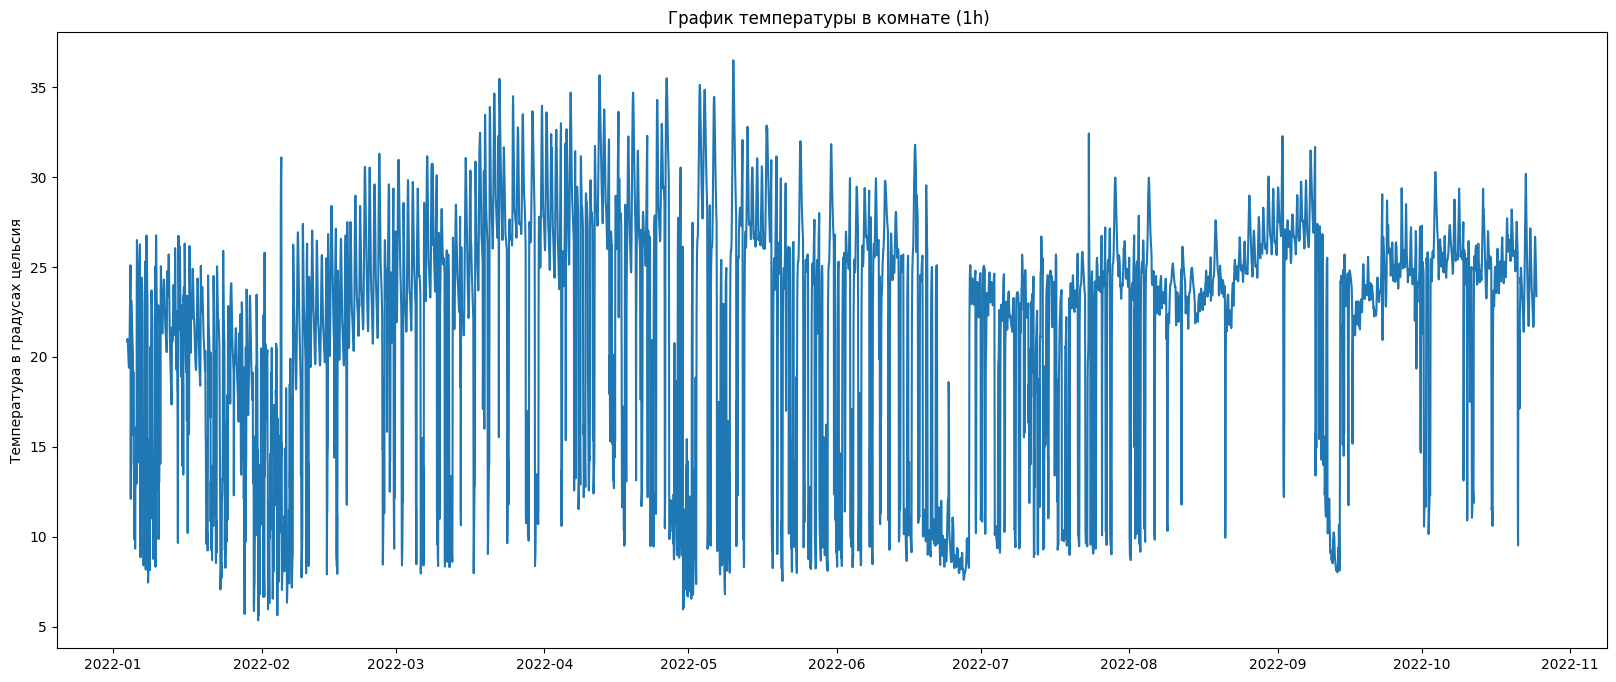

In [148]:
plt.figure(figsize=(20, 8))
plt.plot(df.index, df['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (1h) ")

#### На таком графике мало что понятно из-за сильно скачущих данных. 
#### Попробуем агрегировать на промежутке день, неделя и месяц.

/var/folders/sl/trjmdn1x1qqd0p90hsmrc_440000gn/T/ipykernel_77831/1495066560.py:4: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month = df.resample('1m').mean()


Text(0.5, 1.0, 'График температуры в комнате')

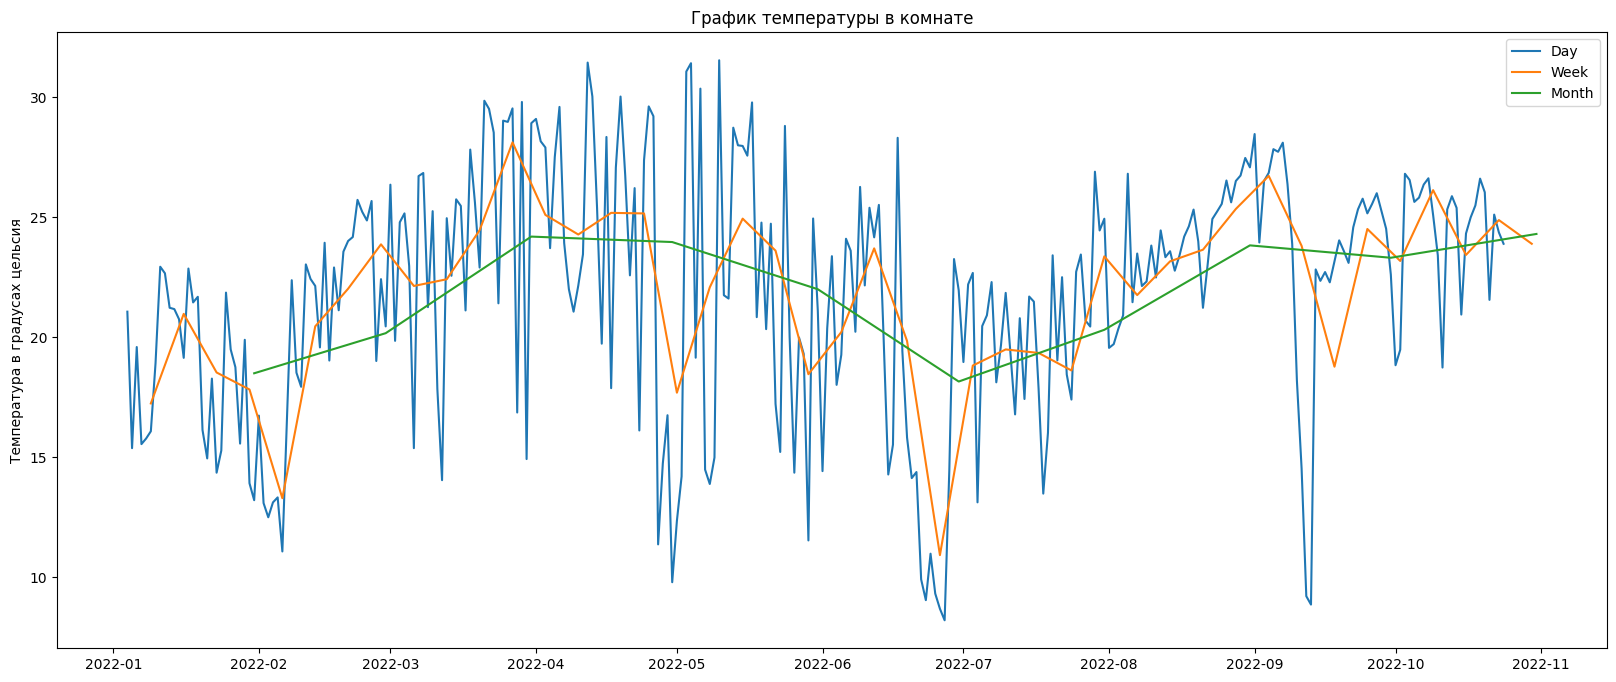

In [149]:
plt.figure(figsize=(20, 8))
df_days = df.resample('1D').mean()
df_week = df.resample('1W').mean()
df_month = df.resample('1m').mean()
plt.plot(df_days.index, df_days['Hourly_Temp'], label='Day')
plt.plot(df_week.index, df_week['Hourly_Temp'], label='Week')
plt.plot(df_month.index, df_month['Hourly_Temp'], label='Month')
plt.legend()
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате")


#### Все еще некрасиво и мало понятно. 
#### Но уже можно заметить, что температура в середине весны и конце осени стабильно выше, чем летом и зимой
Вполне возможно это связано с сезоном включения/отключения отопления в доме. А просадка зимой говорит о том, что отопления не хвататет чтобы победить морозы. Летом, понятное дело, стараются охладиться от внешней жары поэтому температура ниже.
Также стоит исследовать дни, в которые температура опускалась до ±10 градусов тепла: они выглядят подозрительно. Особенно февраль, май, июль и сентябрь. Возможно в данные дни были замеры были проведены неправильно, либо случались аварии в отопительной системе.

In [150]:
df_less_12 = df_days[df_days['Hourly_Temp'] <= 12]
df_less_12

,Hourly_Temp
Datetime,
2022-02-06,11.071250
2022-04-27,11.366042
2022-04-30,9.788833
2022-05-29,11.530917
2022-06-22,9.906250
2022-06-23,9.042292
2022-06-24,10.977792
2022-06-25,9.315375
2022-06-26,8.681833


In [151]:
# Топ-15 самых холодных дней по среднесуточой температуре.
df_days['Hourly_Temp'].sort_values(ascending=True).head(15)

Datetime
2022-06-27     8.202833
2022-06-26     8.681833
2022-09-13     8.857000
2022-06-23     9.042292
2022-09-12     9.206667
2022-06-25     9.315375
2022-04-30     9.788833
2022-06-22     9.906250
2022-06-24    10.977792
2022-02-06    11.071250
2022-04-27    11.366042
2022-05-29    11.530917
2022-05-01    12.348625
2022-02-03    12.495458
2022-02-02    13.086167
Name: Hourly_Temp, dtype: float64

####  Теперь попроубем уловить суточную сезонность, для этого построим график нескольких дней

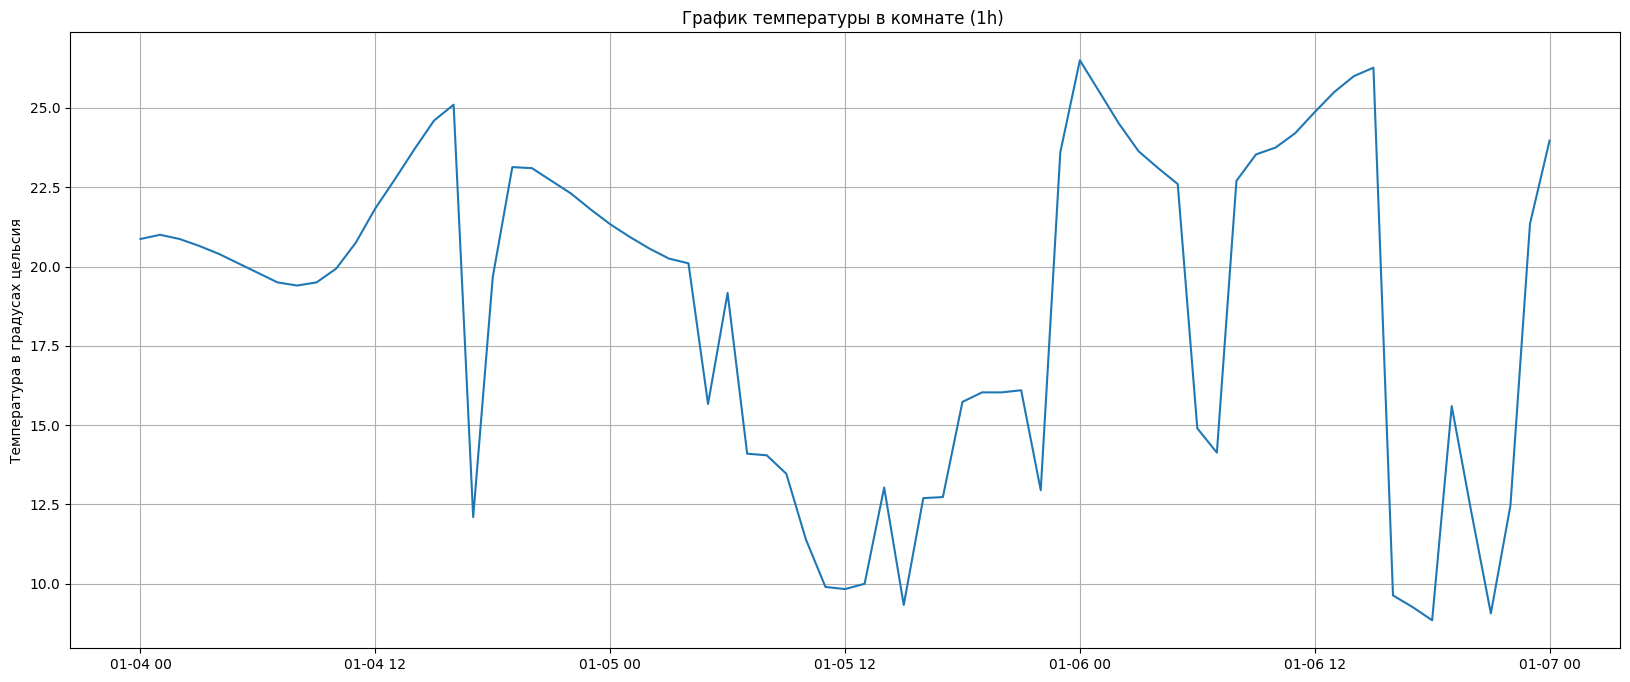

In [152]:
plt.figure(figsize=(20, 8))
dt = df.iloc[:73]
plt.plot(dt.index, dt['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (1h) ")
plt.grid()

Text(0.5, 1.0, 'График температуры в комнате (3h)')

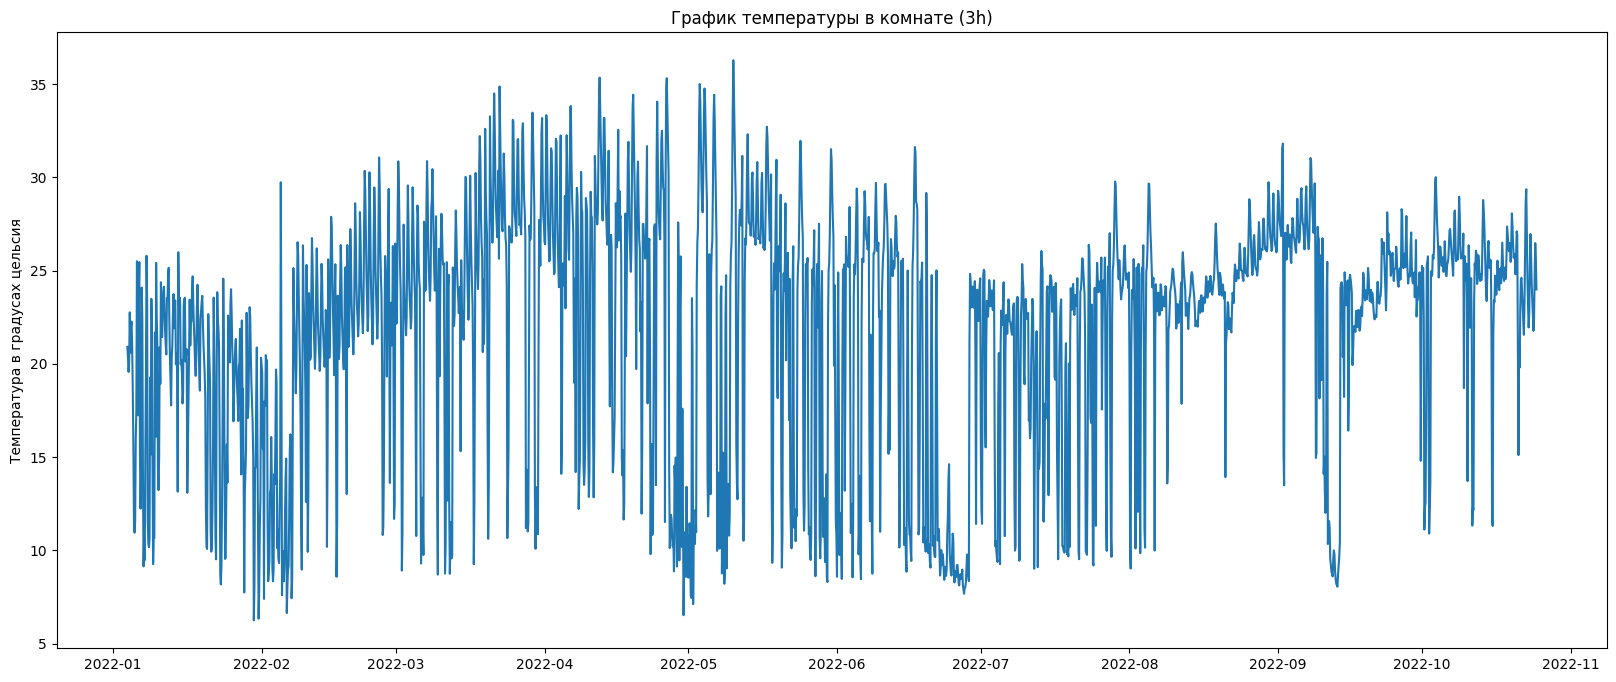

In [153]:
plt.figure(figsize=(20, 8))
dt = df.resample('3h').mean()
plt.plot(dt.index, dt['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (3h)")

Text(0.5, 1.0, 'График температуры в комнате (3h) ')

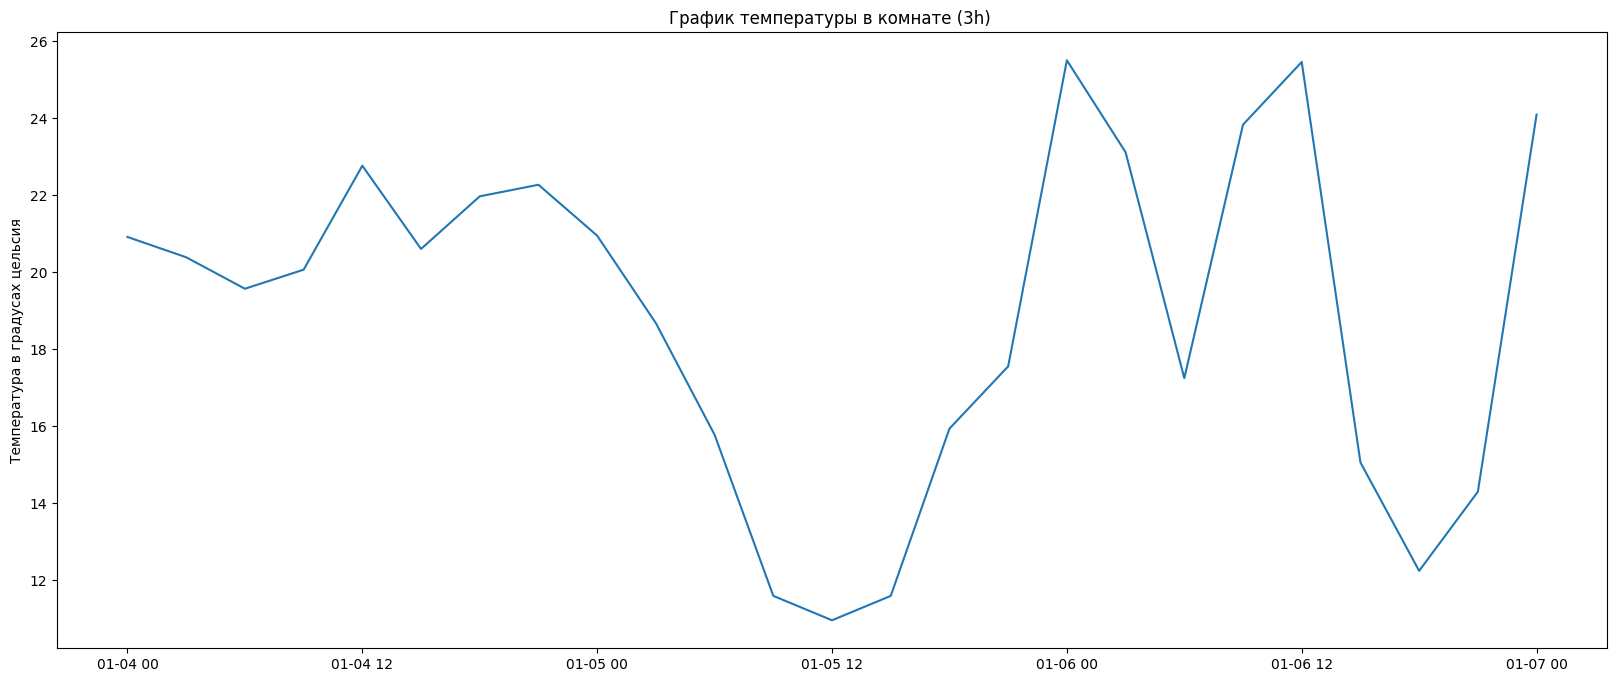

In [154]:
plt.figure(figsize=(20, 8))
dt = dt.iloc[:25]
plt.plot(dt.index, dt['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (3h) ")

#### Данные действительно ведут себя странно и имеют резкие скачки температуры в диапазоне одного часа.
#### Попробуем применить сглаживание вместо простой агрегации

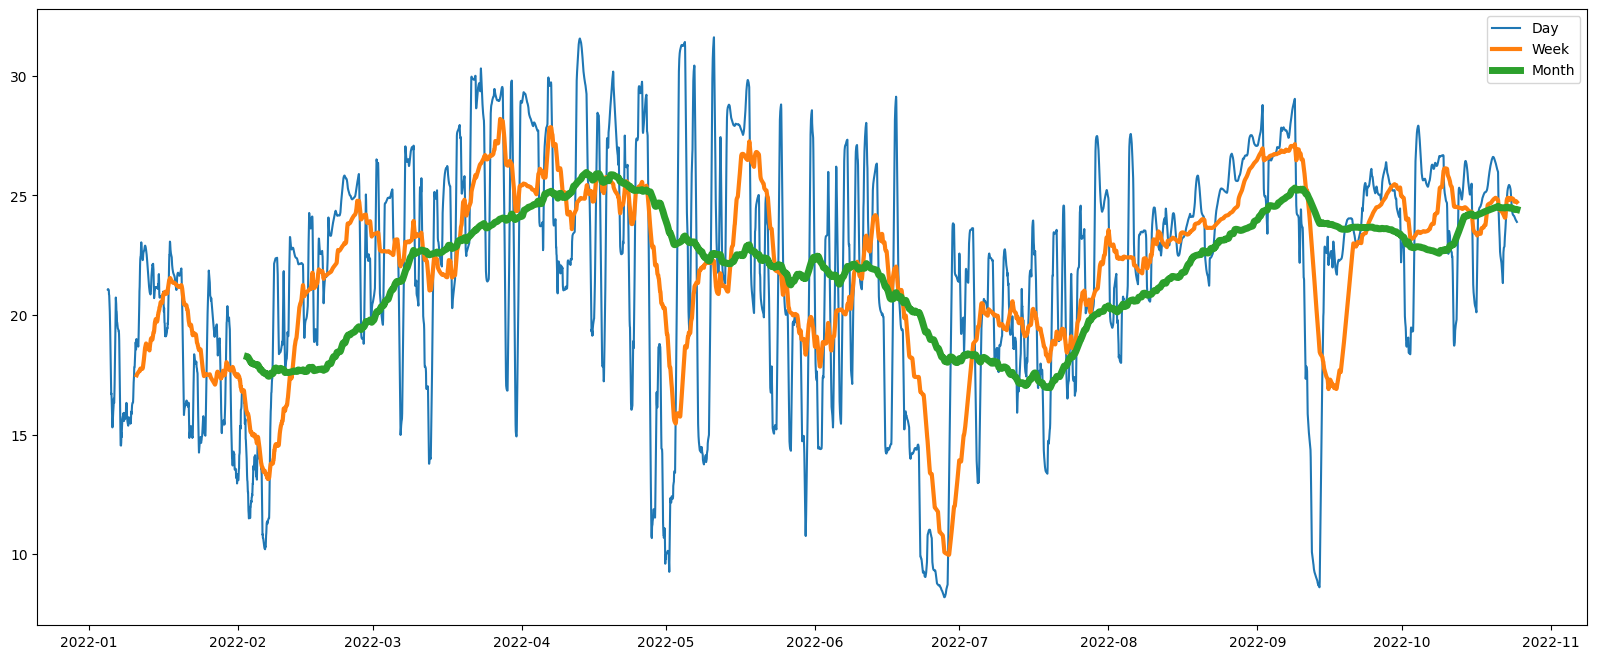

In [155]:
plt.figure(figsize=(20, 8))
df_roll_days = df.rolling(window=24).mean()
df_roll_week = df.rolling(window=168).mean()
df_roll_month = df.rolling(window=720).mean()
plt.plot(df_roll_days.index, df_roll_days['Hourly_Temp'], label='Day')
plt.plot(df_roll_week.index, df_roll_week['Hourly_Temp'], label='Week', lw=3)
plt.plot(df_roll_month.index, df_roll_month['Hourly_Temp'], label='Month', linewidth=5)
plt.legend()

Text(0.5, 1.0, 'График температуры в комнате (3h)')

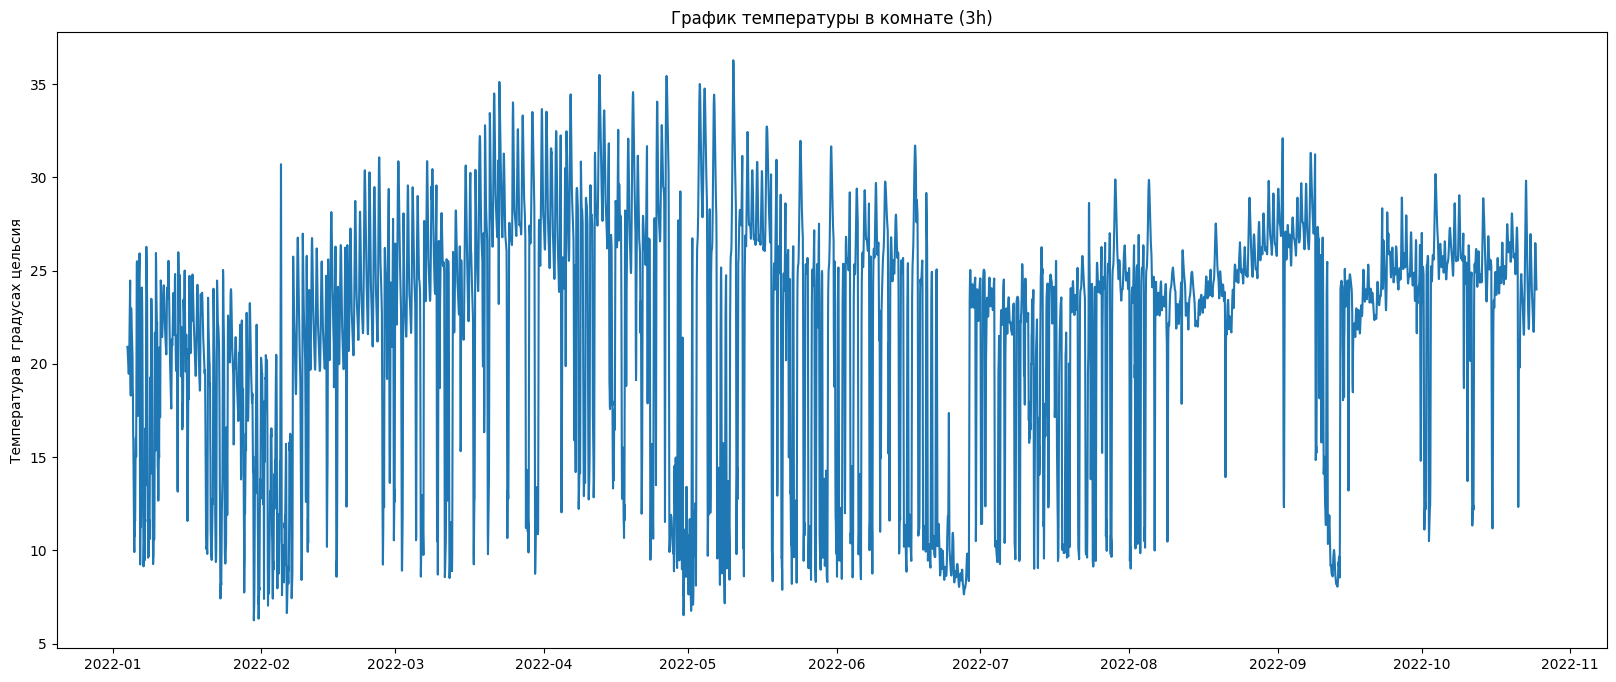

In [156]:
plt.figure(figsize=(20, 8))
dt = df.rolling(window=3).mean()
plt.plot(dt.index, dt['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (3h)")

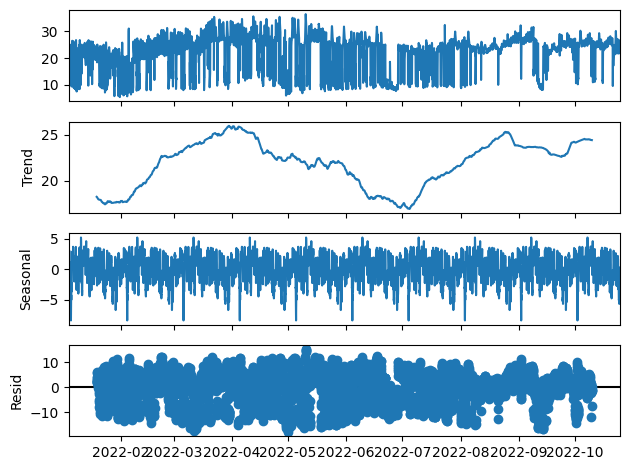

In [157]:
seasonal_decompose(df, model = 'additive', period = 720).plot()
plt.show()

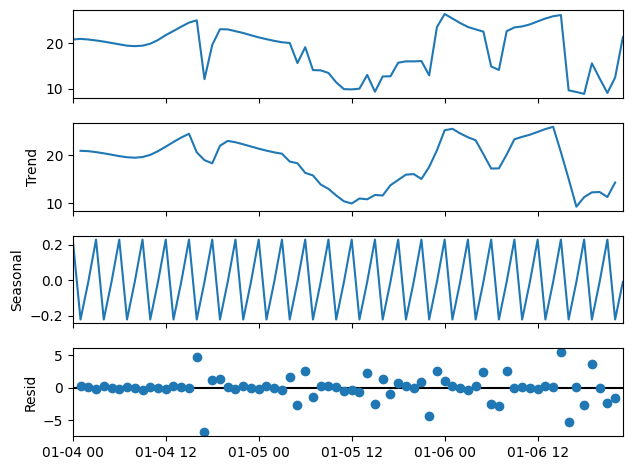

In [158]:
seasonal_decompose(df.head(72), model = 'additive', period = 3).plot()
plt.show()

<Axes: >

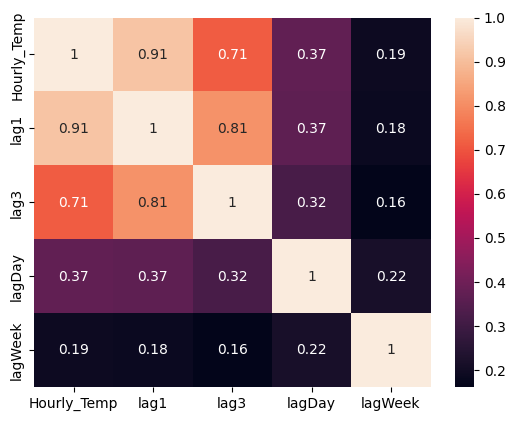

In [159]:

df['lag1'] = df['Hourly_Temp'].shift(1, axis = 0)
df['lag3'] = df['Hourly_Temp'].shift(3, axis = 0)
df['lagDay'] = df['Hourly_Temp'].shift(24, axis = 0)
df['lagWeek'] = df['Hourly_Temp'].shift(168, axis = 0)


sns.heatmap(df.corr(), annot = True)

#### Как и ожидалось, что чем ближе мы к настоящему времени, тем точнее будет предсказание. 
#### Следовательно гадать температуру будем на 1 или 3 часа вперед.

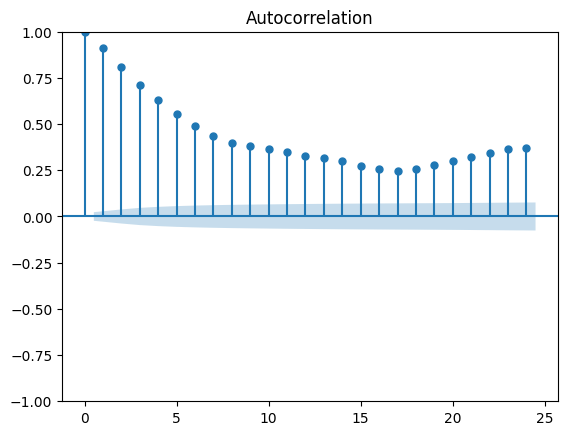

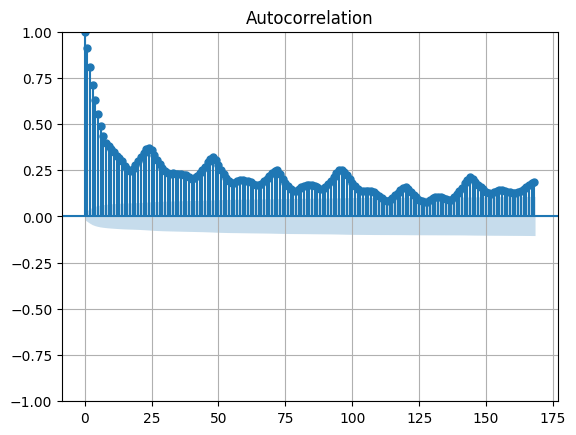

In [160]:
plot_acf(df['Hourly_Temp'], lags = 24)
plot_acf(df['Hourly_Temp'], lags = 168)
plt.grid(True)
plt.show()

#### А отсюда видим, что идет затухание для корреляции температуры. Плюс то, что корреляция значима.

#### Разобьем данные на тренировочные и тестовые, затем протестируем две модельки

In [172]:
def metrics(true, pred):
    print('R2:', r2_score(true, pred))
    print('MAE:', mean_absolute_error(true, pred))
    print('RMSE:', mean_squared_error(true, pred)**0.5)

In [183]:
df.index.freq = 'h'
steps = round(df.shape[0] * 0.2)
df_train = df[:-steps]
df_test  = df[-steps:]
print(df_train.shape, df_test.shape)

(5645, 5) (1411, 5)


In [196]:
forecaster = ForecasterRecursive(
    regressor = LinearRegression(),
    lags = 1)

forecaster.fit(df_train['Hourly_Temp'])
forecaster

/var/folders/sl/trjmdn1x1qqd0p90hsmrc_440000gn/T/ipykernel_77831/925496294.py:1: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster = ForecasterRecursive(


=================== 
ForecasterRecursive 
=================== 
Estimator: LinearRegression 
Lags: [1] 
Window features: None 
Window size: 1 
Series name: Hourly_Temp 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2022-01-04 00:00:00'), Timestamp('2022-08-27 04:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False,
    'tol': 1e-06} 
fit_kwargs: {} 
Creation date: 2026-04-11 11:47:07 
Last fit date: 2026-04-11 11:47:07 
Skforecast version: 0.21.0 
Python version: 3.13.7 
Forecaster id: None

In [197]:
steps = len(df_test)

y_pred = forecaster.predict(steps = steps)
y_pred.head()

2022-08-27 05:00:00    25.716070
2022-08-27 06:00:00    25.321337
2022-08-27 07:00:00    24.962260
2022-08-27 08:00:00    24.635618
2022-08-27 09:00:00    24.338481
Freq: h, Name: pred, dtype: float64

In [198]:
metrics(df_test['Hourly_Temp'], y_pred)

R2: -0.30142381625220027
MAE: 4.740631691669345
RMSE: 5.414404910795261


# Выводы

#### Можно сказать, что данные достаточно плохи, чтобы строить по ним модель машинного обучения. Это стало заметно на стадии анализа дневных температур: огромные скачки (±12 градусов) в течение одного-двух часов.